# 2020년 건강검진 일부 데이터 -> 산점도 그래프

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import seaborn as sns

In [2]:
# 데이터 불러오기
data = pd.read_excel('health_screenings_2020_1000ea.xlsx')

In [3]:
data.shape

(1000, 30)

In [4]:
data.head()

,year,city_code,gender,age_code,height,weight,waist,eye_left,eye_right,hear_left,...,serum,AST,ALT,GTP,smoking,drinking,oral_check,dental_caries,tartar,open_date
0,2020,36,1,9,165,60,72.1,1.2,1.5,1,...,1.1,21.0,27.0,21.0,1,0,0,NaN,NaN,2021-12-29
1,2020,27,2,13,150,65,81.0,0.8,0.8,1,...,0.5,18.0,15.0,15.0,1,0,0,NaN,NaN,2021-12-29
2,2020,11,2,12,155,55,70.0,0.6,0.7,1,...,0.7,27.0,25.0,7.0,1,0,0,NaN,NaN,2021-12-29
3,2020,31,1,13,160,70,90.8,1.0,1.0,1,...,1.2,65.0,97.0,72.0,1,0,1,0.0,0.0,2021-12-29
4,2020,41,2,12,155,50,75.2,1.5,1.2,1,...,0.7,18.0,17.0,14.0,1,0,0,NaN,NaN,2021-12-29


## 키, 몸무게 데이터를 가지고 산점도 그래프 그리기

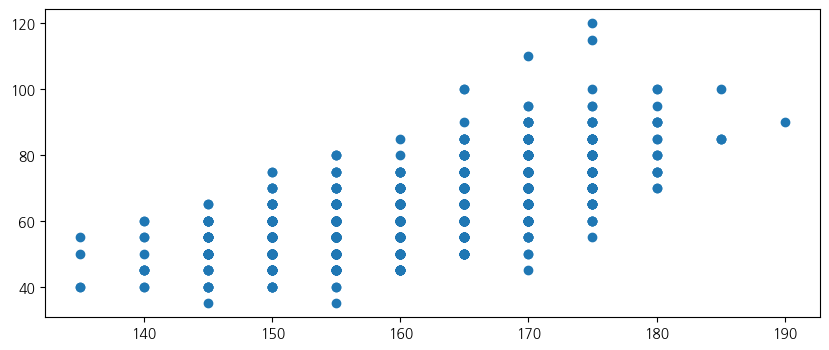

In [5]:
heightdata = data['height'] # 키
weightdata = data['weight'] # 몸무게

plt.figure(figsize=(10, 4))
plt.scatter(heightdata, weightdata)

plt.show()

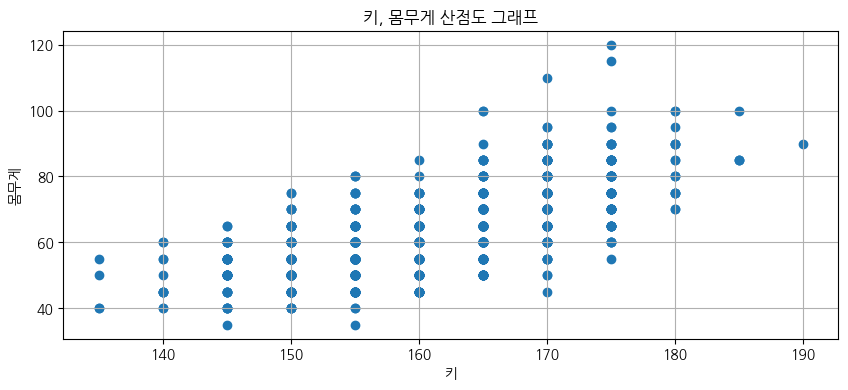

In [6]:
plt.figure(figsize=(10, 4))
plt.scatter(heightdata, weightdata)

plt.xlabel('키')
plt.ylabel('몸무게')
plt.title('키, 몸무게 산점도 그래프')
plt.grid()
plt.show()

## 수축기 혈압, 이완기 혈압, 공복 혈당 그룹 산점도 그래프

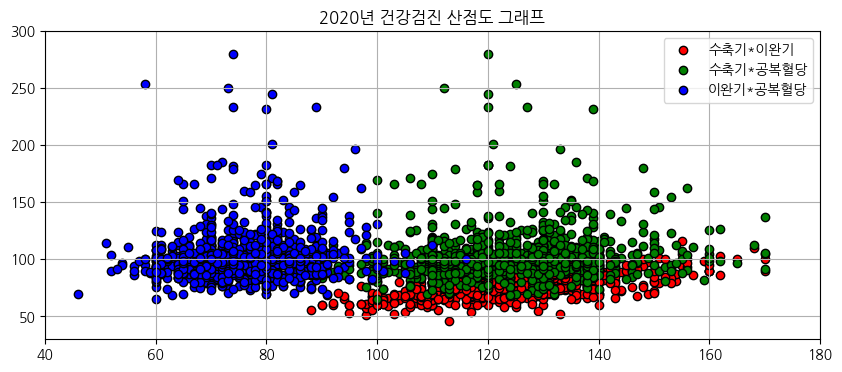

In [7]:
systolic_data = data['systolic']
diastolic_data = data['diastolic']
blood_sugar_data = data['blood_sugar']

plt.figure(figsize=(10, 4))
plt.scatter(systolic_data, diastolic_data, color='r', edgecolor='k', label='수축기*이완기')
plt.scatter(systolic_data, blood_sugar_data, color='g', edgecolor='k', label='수축기*공복혈당')
plt.scatter(diastolic_data, blood_sugar_data, color='b', edgecolor='k', label='이완기*공복혈당')

plt.xlim(40, 180)
plt.ylim(30, 300)
plt.title('2020년 건강검진 산점도 그래프')
plt.legend()
plt.grid()
plt.show()

## 여성 키 히스토그램

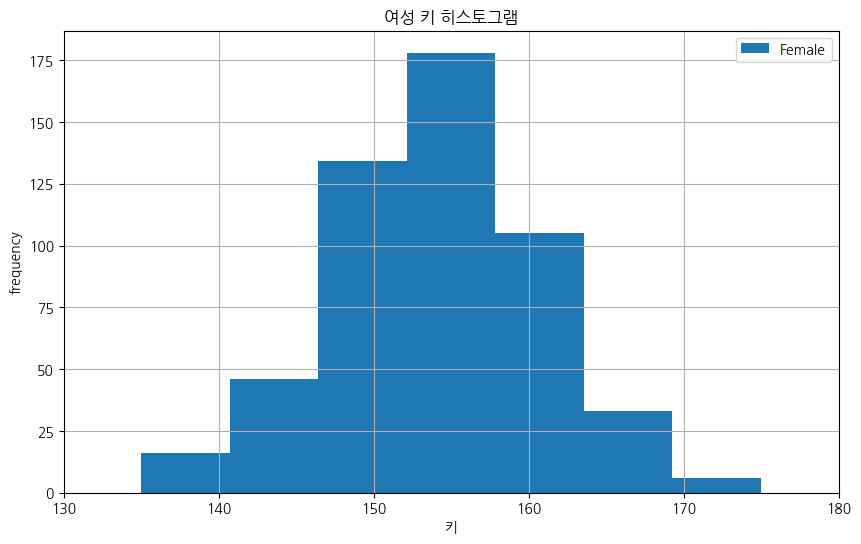

In [8]:
female_data = data.loc[data.gender==2, ['gender', 'height']]

plt.figure(figsize=(10, 6))
plt.hist(female_data['height'], bins=7, label='Female') # bins 구간

plt.xlim(130, 180)
plt.xlabel('키')
plt.ylabel('frequency')
plt.title('여성 키 히스토그램')
plt.legend()
plt.grid()
plt.show()

## 남성, 여성 키 그룹 히스토그램

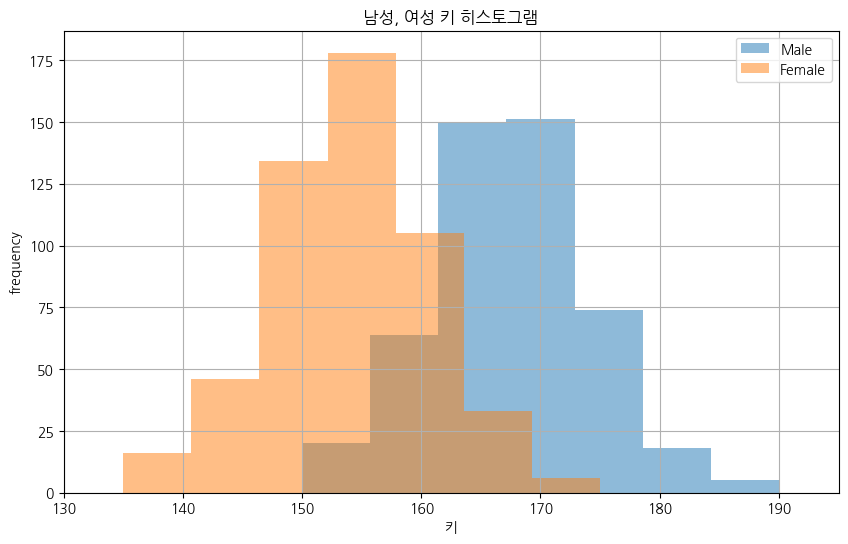

In [9]:
male_data = data.loc[data.gender==1, ['gender', 'height']]
female_data = data.loc[data.gender==2, ['gender', 'height']]

plt.figure(figsize=(10, 6))
plt.hist(male_data['height'], bins=7, alpha=0.5, label='Male') # alpha 투명도
plt.hist(female_data['height'], bins=7, alpha=0.5, label='Female')

plt.xlim(130, 195)
plt.xlabel('키')
plt.ylabel('frequency')
plt.title('남성, 여성 키 히스토그램')
plt.legend()
plt.grid()
plt.show()

# 상자수염 그래프

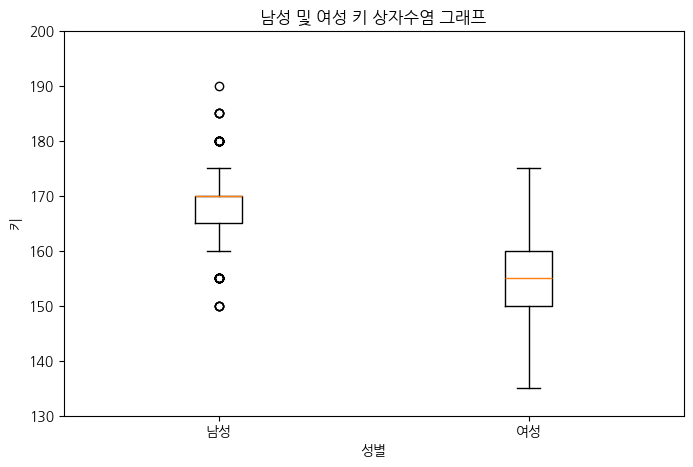

In [10]:
height = np.array([male_data['height'], female_data['height']], dtype=object)

plt.figure(figsize=(8, 5))
plt.boxplot(height, tick_labels=['남성', '여성'])

plt.ylim(130, 200)
plt.xlabel('성별')
plt.ylabel('키')
plt.title('남성 및 여성 키 상자수염 그래프')
plt.show()



## 연습문제 4번

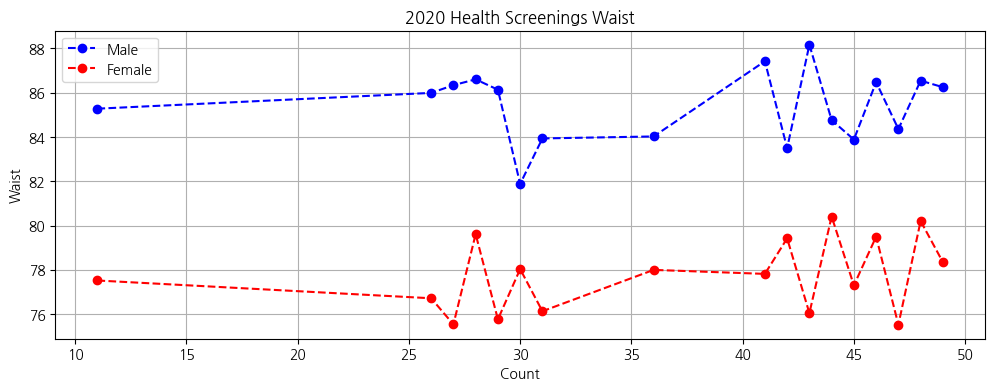

In [11]:
data3 = data.loc[:, ['city_code', 'gender', 'waist']]

male_data = data3[data3['gender'] == 1].groupby('city_code')['waist'].mean()
female_data = data3[data3['gender'] == 2].groupby('city_code')['waist'].mean()

plt.figure(figsize=(12, 4))

plt.plot(male_data, color='b', marker='o', linestyle='--', label='Male' )
plt.plot(female_data, color='r', marker='o', linestyle='--', label='Female')

plt.xlabel('Count')
plt.ylabel('Waist')
plt.title('2020 Health Screenings Waist')
plt.legend()
plt.grid()
plt.show()

## 연습문제 5번

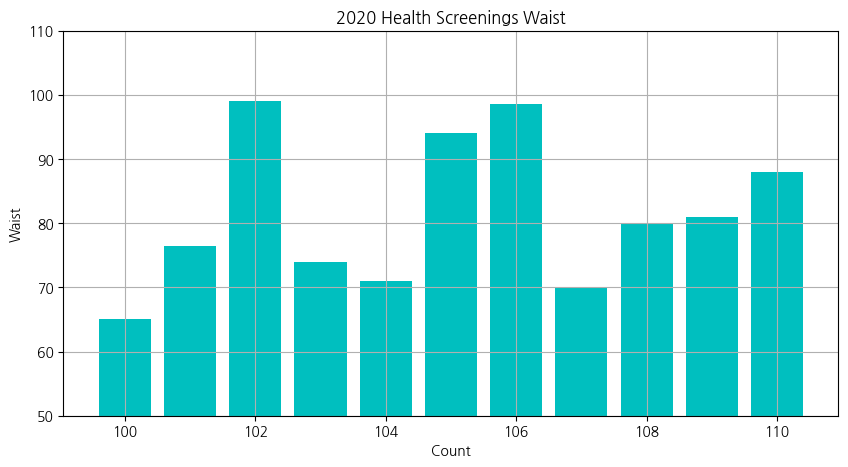

In [12]:
data3 = data.loc[:, ['city_code', 'gender', 'waist']]

waistData = data3.loc[100:110,['waist']]

plt.figure(figsize=(10, 5))

plt.bar(waistData.index, waistData['waist'], color='c')

plt.ylim(50, 110)
plt.xlabel('Count')
plt.ylabel('Waist')
plt.title('2020 Health Screenings Waist')
plt.grid()
plt.show()

## 연습문제 6번

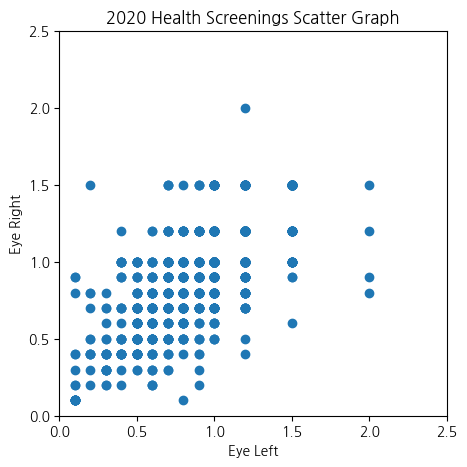

In [13]:
lEyeData = data['eye_left']
rEyeData = data['eye_right']

plt.figure(figsize=(5,5))

plt.scatter(lEyeData, rEyeData)

plt.xlim(0, 2.5)
plt.ylim(0, 2.5)
plt.xlabel('Eye Left')
plt.ylabel('Eye Right')
plt.title('2020 Health Screenings Scatter Graph')
plt.show()

## 연습문제 7번

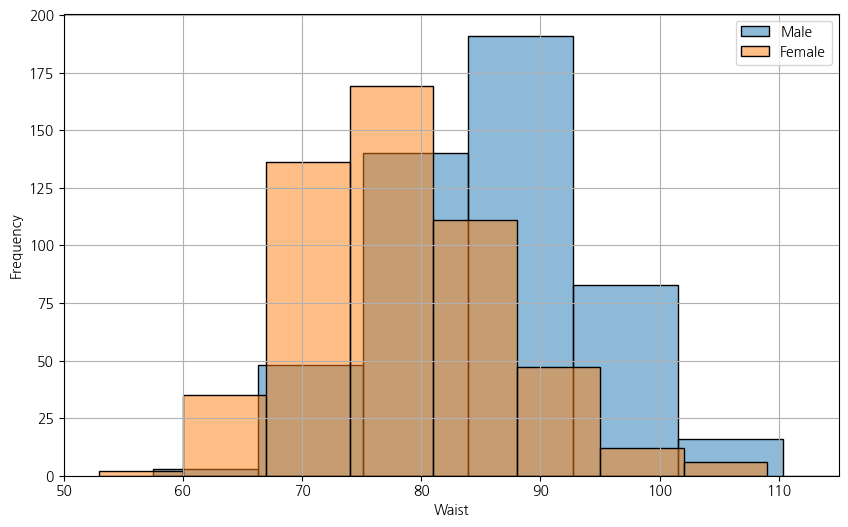

In [14]:
data3 = data.loc[:, ['city_code', 'gender', 'waist']]
male_data = data3.loc[data3['gender'] == 1, ['gender', 'waist']]
female_data = data3.loc[data3['gender'] == 2, ['gender', 'waist']]

plt.figure(figsize=(10, 6))

sns.histplot(male_data['waist'], bins=8, alpha=0.5, label='Male')
sns.histplot(female_data['waist'], bins=8, alpha=0.5, label='Female')

plt.xlim(50, 115)
plt.xlabel('Waist')
plt.ylabel('Frequency')
plt.legend()
plt.grid()
plt.show()

## 연습문제 8번

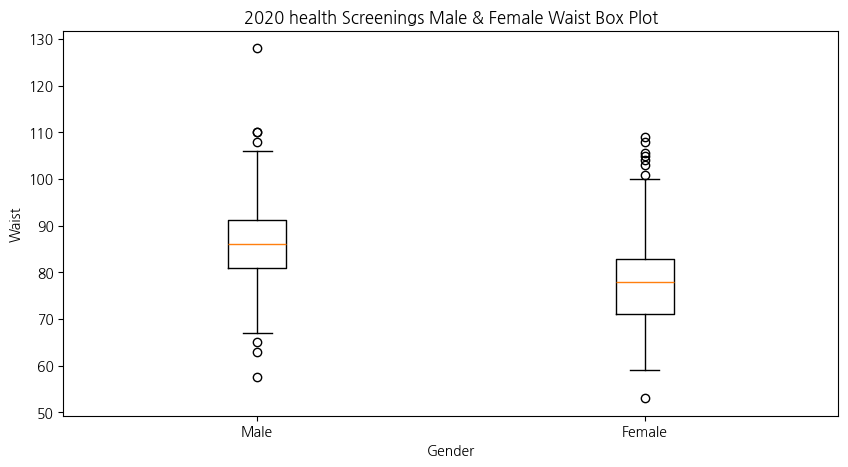

In [18]:
mandata = data3.loc[data3.gender==1, ['gender', 'waist']]
womandata = data3.loc[data3.gender==2, ['gender', 'waist']]

male = np.array(mandata['waist'], dtype=object)
female = np.array(womandata['waist'], dtype=object)

plt.figure(figsize=(10, 5))

plt.boxplot([male, female], tick_labels=['Male', 'Female'])

plt.xlabel('Gender')
plt.ylabel('Waist')
plt.title('2020 health Screenings Male & Female Waist Box Plot')
plt.show()

## 연습문제 9번

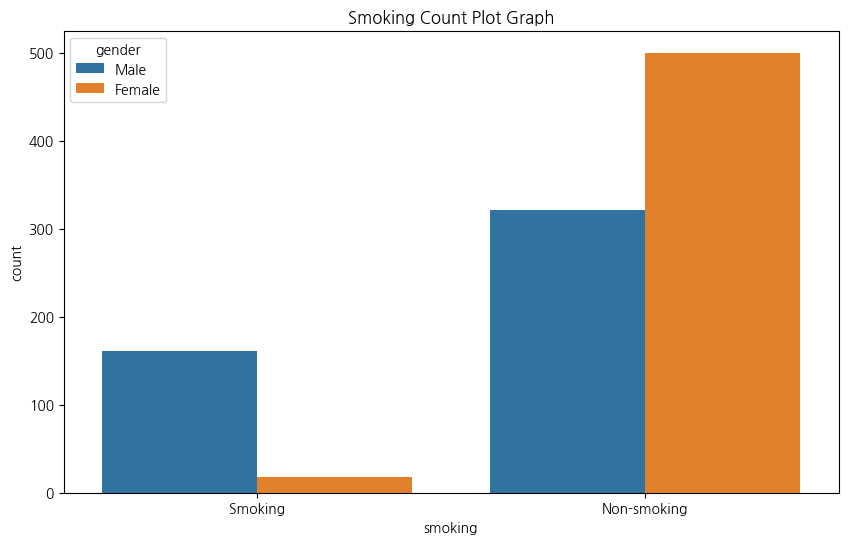

In [ ]:
data6 = data.loc[:,['gender', 'height', 'weight', 'waist', 'drinking', 'smoking']]

data6['gender'] = data6['gender'].map({1:'Male', 2:'Female'}) .map({...})
data6['drinking'] = data6['drinking'].map({0:'Non-drinking', 1:'Drinking'})
data6['smoking'] = data6['smoking'].map({1:'Non-smoking', 2:'Non-smoking', 3:'Smoking'})

smoking = data6.groupby(['gender','smoking'])['smoking'].count()
smoking = smoking.to_frame(name='count')
smoking = smoking.reset_index()

plt.figure(figsize=(10,6))

sns.countplot(data=data6, x='smoking', hue='gender', order=['Smoking','Non-smoking'])

plt.title('Smoking Count Plot Graph')
plt.show()